
QUANTUM CIRCUIT
        ┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 

MEASUREMENT RESULTS
Shots       0 Count     1 Count     P(0)        P(1)        
----------------------------------------------------------------------
100         42          58          0.5200      0.4800      
1000        508         492         0.4970      0.5030      
10000       5048        4952        0.5079      0.4921      


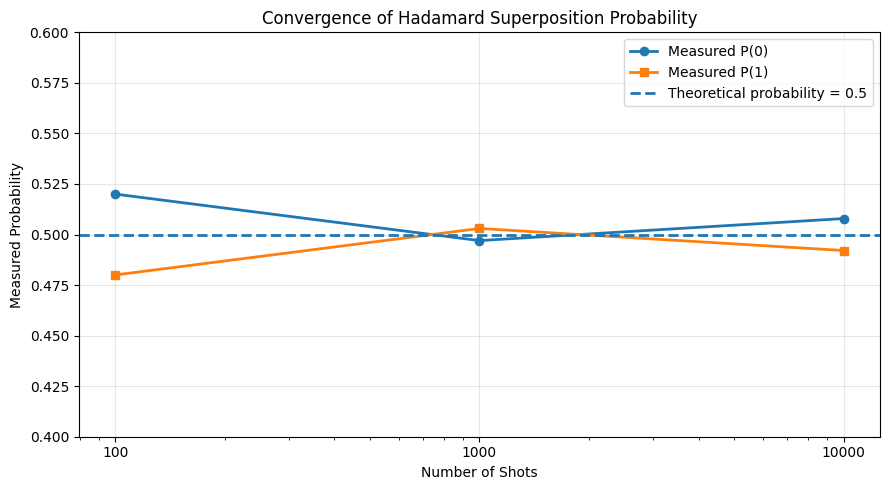

In [2]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

shots_list = [100, 1000, 10000]

qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()

print("\nQUANTUM CIRCUIT")
print("=" * 50)
print(qc.draw())

sampler = StatevectorSampler()

results = []

for shots in shots_list:
    result = sampler.run([qc], shots=shots).result()
    counts = result[0].data.meas.get_counts()

    zeros = counts.get("0", 0)
    ones = counts.get("1", 0)

    p0 = zeros / shots
    p1 = ones / shots

    results.append((shots, p0, p1))

print("\nMEASUREMENT RESULTS")
print("=" * 70)
print(f"{'Shots':<12}{'0 Count':<12}{'1 Count':<12}{'P(0)':<12}{'P(1)':<12}")
print("-" * 70)

for shots, p0, p1 in results:
    result = sampler.run([qc], shots=shots).result()
    counts = result[0].data.meas.get_counts()

    zeros = counts.get("0", 0)
    ones = counts.get("1", 0)

    print(
        f"{shots:<12}"
        f"{zeros:<12}"
        f"{ones:<12}"
        f"{p0:<12.4f}"
        f"{p1:<12.4f}"
    )

shots_values = [x[0] for x in results]
p0_values = [x[1] for x in results]
p1_values = [x[2] for x in results]

plt.figure(figsize=(9, 5))

plt.plot(
    shots_values,
    p0_values,
    marker="o",
    linewidth=2,
    label="Measured P(0)"
)

plt.plot(
    shots_values,
    p1_values,
    marker="s",
    linewidth=2,
    label="Measured P(1)"
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=2,
    label="Theoretical probability = 0.5"
)

plt.xscale("log")

plt.xlabel("Number of Shots")
plt.ylabel("Measured Probability")

plt.title("Convergence of Hadamard Superposition Probability")

plt.xticks(shots_values, ["100", "1000", "10000"])

plt.ylim(0.4, 0.6)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()